<h1 align = "center" > CYBERSECURITY ATTACK TYPE PREDICTION ML </h1>

## 1. Data Loading and Inspection
### 1.1 Load dataset
### 1.2 Inspect basics — shape, columns, head, info, missing values
### 1.3 Visualise missingness — missingno matrix (just look, don't fix yet)

## 2. Data Type Fixes
### 2.1 Examining missing value and unique/ drop columns 
### 2.2 Split numeric vs categorical columns
### 2.3 Fix data types — Timestamp to datetime, coerce numeric strings

## 3. Target Variable Analysis
### 3.1 Select target variable — Attack Type, understand
### 3.2 Plot target distribution
### 3.3 Assess class imbalance

## 4. Exploratory Data Analysis
### 4.1 Examining numeric varibles
### 4.2 Examining Categorical Varibles
### 4.2 Anomaly Score

## 5. Attack Pattern Exploration
### 5.1 Numerical Varible - Attacktype 
### 5.1 Attack Type vs Network Segment
### 5.2 Attack Type vs Traffic Type
### 5.3 Attack Type vs Protocol

## 6. Correlation and Insights
### 6.1 Correlation heatmap — numeric features only
### 6.2 Strongest relationships — findings

## 7. Findings and Feature Selection
### 7.1 Key patterns found
### 7.2 Interesting insights
### 7.3 Candidate prediction features

## 8. Data Cleaning and Preparation
### 8.1 Drop useless columns — IPs, Payload, User Info etc
### 8.2 Handle missing values — median for numeric, mode for categorical
### 8.3 Drop duplicates
### 8.4 Verify — confirm zero nulls

## 9. Feature Engineering
### 9.1 Define X and y
### 9.2 Remove leakage columns — Attack Signature, IDS/IPS Alerts, Malware Indicators
### 9.3 One-hot encode categorical columns
### 9.4 Apply StandardScaler to numeric features

## 10. Data Splitting and Validation
### 10.1 Train-test split — 80/20, stratified
### 10.2 5-fold cross-validation
### 10.3 Record baseline cross-validation score

## 11. Baseline Model — Logistic Regression
### 11.1 Train Logistic Regression
### 11.2 Evaluate — accuracy, precision, recall, F1

## 12. Preprocessing Review
### 12.1 Document all preprocessing decisions
### 12.2 Document leakage checks

## 13. Decision Tree Model
### 13.1 Train Decision Tree
### 13.2 Evaluate and compare vs baseline
### 13.3 Feature importance — top 10

## 14. Random Forest Model
### 14.1 Train Random Forest
### 14.2 Tune n_estimators
### 14.3 Tune max_depth
### 14.4 Model comparison table — Logistic Regression vs Decision Tree vs Random Forest

## 15. Finalisation and Portfolio Output
### 15.1 Error analysis — which classes does the model struggle with?
### 15.2 Lock final model and results
### 15.3 Save visuals to /images
### 15.4 Write report.md
### 15.5 Write README.md
### 15.6 Restart kernel — run all cells, zero errors
### 15.7 Push to GitHub

#### 1.1 importing libaries


In [1]:
import numpy as np
import pandas as pd
import warnings 
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns



# 1.2 Loading the dataset

In [2]:
df = pd.read_csv("../data/cybersecurity_attacks.csv")


In [3]:
df

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,2023-05-26 14:08:42,26.36.109.26,121.100.75.240,31005,6764,UDP,1428,Control,HTTP,Quibusdam ullam consequatur consequuntur accus...,...,Logged,Medium,Adira Madan,Mozilla/5.0 (iPad; CPU iPad OS 14_2_1 like Mac...,Segment A,"Nashik, Manipur",NaN,Log Data,Alert Data,Firewall
39996,2023-03-27 00:38:27,17.21.163.81,196.108.134.78,2553,28091,UDP,1184,Control,HTTP,Quaerat neque esse. Animi expedita natus commo...,...,Logged,High,Rati Dara,Mozilla/5.0 (Windows; U; Windows 98; Win 9x 4....,Segment C,"Vadodara, Mizoram",60.51.30.46,Log Data,NaN,Firewall
39997,2022-03-31 01:45:49,162.35.217.57,98.107.0.15,22505,25152,UDP,1043,Data,DNS,Enim at aspernatur illum. Saepe numquam eligen...,...,Blocked,Low,Samiha Joshi,Mozilla/5.0 (Windows; U; Windows NT 4.0) Apple...,Segment C,"Mahbubnagar, Himachal Pradesh",NaN,Log Data,Alert Data,Server
39998,2023-09-22 18:32:38,208.72.233.205,173.79.112.252,20013,2703,UDP,483,Data,FTP,Officiis dolorem sed harum provident earum dis...,...,Ignored,Low,Rasha Chauhan,Mozilla/5.0 (X11; Linux i686) AppleWebKit/536....,Segment B,"Rourkela, Arunachal Pradesh",137.76.130.8,Log Data,NaN,Server


#### 1.2 Reconigsie the varible in the dataset

## Dataset Variables Explanation

- Timestamp: Date and time when the network event occurred  
- Source IP Address: IP address where the traffic originated  
- Destination IP Address: IP address where the traffic was sent to  
- Source Port: Port number used by the source device  
- Destination Port: Port number used by the destination service  
- Protocol: Type of network protocol used (TCP, UDP, ICMP, etc.)  
- Packet Length: Size of the data packet being transmitted  
- Packet Type: Type of packet (Data or Control)  
- Traffic Type: Type of network service (HTTP, DNS, FTP, etc.)  
- Payload Data: Actual content/data carried in the packet  
- Action Taken: Security response (Logged, Blocked, Ignored)  
- Severity Level: Risk level of the event (Low, Medium, High)  
- User Information: User associated with the network activity  
- Device Information: Device/browser/OS details generating the traffic  
- Network Segment: Internal network zone (e.g., Segment A, B, C)  
- Geo-location Data: Physical location of the IP address  
- Proxy Information: Proxy IP if traffic is routed through a proxy  
- Firewall Logs: Firewall recording status of the event  
- IDS/IPS Alerts: Intrusion Detection/Prevention system alerts  
- Log Source: Origin of the log data (Firewall, Server, etc.)

1.3 Overview the dataset

In [4]:
df.shape

(40000, 25)

In [5]:
list_of_null = []

for i in df.columns:
    holder = df[i].isnull().sum()
    if holder > 0:
        list_of_null.append(i)

print(list_of_null)

['Malware Indicators', 'Alerts/Warnings', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts']


In [6]:
df.isnull().sum()

Timestamp                     0
Source IP Address             0
Destination IP Address        0
Source Port                   0
Destination Port              0
Protocol                      0
Packet Length                 0
Packet Type                   0
Traffic Type                  0
Payload Data                  0
Malware Indicators        20000
Anomaly Scores                0
Alerts/Warnings           20067
Attack Type                   0
Attack Signature              0
Action Taken                  0
Severity Level                0
User Information              0
Device Information            0
Network Segment               0
Geo-location Data             0
Proxy Information         19851
Firewall Logs             19961
IDS/IPS Alerts            20050
Log Source                    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  object 
 1   Source IP Address       40000 non-null  object 
 2   Destination IP Address  40000 non-null  object 
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  object 
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  object 
 8   Traffic Type            40000 non-null  object 
 9   Payload Data            40000 non-null  object 
 10  Malware Indicators      20000 non-null  object 
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  object 
 13  Attack Type             40000 non-null  object 
 14  Attack Signature        40000 non-null

## Conclusion 1

* The Data Set consists of **40000 Rows** and **25 Columns**.
* The type of majority the variables in the data set are in **Object type**.
* According to first impressions, there is **quite alot missing value** (NaN Value) in the data set like:['Malware Indicators', 'Alerts/Warnings', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts']
 

## 2. Data Cleaning and Preparation for EDA



### 2.1 Examining missing value and unique/ drop columns 



In [8]:
df.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


In [9]:
unique_num = []
for i in df.columns: 
    x = df[i].value_counts().count()
    unique_num.append(x)

pd.DataFrame(unique_num, index = df.columns, columns=["Total Unique value"])

,Total Unique value
Timestamp,39997
Source IP Address,40000
Destination IP Address,40000
Source Port,29761
Destination Port,29895
Protocol,3
Packet Length,1437
Packet Type,2
Traffic Type,3
Payload Data,40000


In [10]:
percent_unique = []
for col in df.columns:
    n = df[col].nunique()
    pct = round(n / len(df) * 100, 1)
    percent_unique.append(pct)
pd.DataFrame(percent_unique, index = df.columns, columns=["Percent Unique value"])

,Percent Unique value
Timestamp,100.0
Source IP Address,100.0
Destination IP Address,100.0
Source Port,74.4
Destination Port,74.7
Protocol,0.0
Packet Length,3.6
Packet Type,0.0
Traffic Type,0.0
Payload Data,100.0


In [11]:
df.drop(
    ["Source IP Address", "Payload Data",
     "User Information", "Device Information","Destination IP Address", "Proxy Information",'Source Port', 'Destination Port'],
    axis=1,
    inplace=True
)



In [12]:
df.head()


,Timestamp,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,Network Segment,Geo-location Data,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,ICMP,503,Data,HTTP,IoC Detected,28.67,NaN,Malware,Known Pattern B,Logged,Low,Segment A,"Jamshedpur, Sikkim",Log Data,NaN,Server
1,2020-08-26 07:08:30,ICMP,1174,Data,HTTP,IoC Detected,51.50,NaN,Malware,Known Pattern A,Blocked,Low,Segment B,"Bilaspur, Nagaland",Log Data,NaN,Firewall
2,2022-11-13 08:23:25,UDP,306,Control,HTTP,IoC Detected,87.42,Alert Triggered,DDoS,Known Pattern B,Ignored,Low,Segment C,"Bokaro, Rajasthan",Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,UDP,385,Data,HTTP,NaN,15.79,Alert Triggered,Malware,Known Pattern B,Blocked,Medium,Segment B,"Jaunpur, Rajasthan",NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,TCP,1462,Data,DNS,NaN,0.52,Alert Triggered,DDoS,Known Pattern B,Blocked,Low,Segment C,"Anantapur, Tripura",NaN,Alert Data,Firewall


In [13]:
df.nunique()

Timestamp             39997
Protocol                  3
Packet Length          1437
Packet Type               2
Traffic Type              3
Malware Indicators        1
Anomaly Scores         9826
Alerts/Warnings           1
Attack Type               3
Attack Signature          2
Action Taken              3
Severity Level            3
Network Segment           3
Geo-location Data      8723
Firewall Logs             1
IDS/IPS Alerts            1
Log Source                2
dtype: int64

## Conclusion 2

* The DataSet consists alot of  unique values
* I calculated percent of unique value of each row
* if a colums has over 50% it wil be dropped

## 2.2 Split numeric vs categorical columns

In [14]:
df.head()

,Timestamp,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,Network Segment,Geo-location Data,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,ICMP,503,Data,HTTP,IoC Detected,28.67,NaN,Malware,Known Pattern B,Logged,Low,Segment A,"Jamshedpur, Sikkim",Log Data,NaN,Server
1,2020-08-26 07:08:30,ICMP,1174,Data,HTTP,IoC Detected,51.50,NaN,Malware,Known Pattern A,Blocked,Low,Segment B,"Bilaspur, Nagaland",Log Data,NaN,Firewall
2,2022-11-13 08:23:25,UDP,306,Control,HTTP,IoC Detected,87.42,Alert Triggered,DDoS,Known Pattern B,Ignored,Low,Segment C,"Bokaro, Rajasthan",Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,UDP,385,Data,HTTP,NaN,15.79,Alert Triggered,Malware,Known Pattern B,Blocked,Medium,Segment B,"Jaunpur, Rajasthan",NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,TCP,1462,Data,DNS,NaN,0.52,Alert Triggered,DDoS,Known Pattern B,Blocked,Low,Segment C,"Anantapur, Tripura",NaN,Alert Data,Firewall


In [15]:
numeric_var = []
categorical_var = []

for columns in df.columns:
    if df[columns].dtype == "object":
        categorical_var.append(columns)
    else:
        numeric_var.append(columns)

print("Numeric Variables:")
print(numeric_var)

print("\nCategorical Variables:")
print(categorical_var)

Numeric Variables:
['Packet Length', 'Anomaly Scores']

Categorical Variables:
['Timestamp', 'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'Network Segment', 'Geo-location Data', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']


## Conclusion 3:
- The dataset mainly consists of categorical (`object`) type features.
- Only `Packet Length` and `Anomaly Scores` are numerical variables.
- Most columns contain descriptive network and security information, which may require encoding before machine learning can be applied.

## 2.3 Fix data types — Timestamp to datetime, coerce numeric strings

In [16]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

In [17]:
df.drop(["Timestamp"], axis=1, inplace= True)

In [18]:
categorical_var.remove("Timestamp")
numeric_var.append("Hour")
numeric_var.append("DayOfWeek")

In [19]:
categorical_var


['Protocol',
 'Packet Type',
 'Traffic Type',
 'Malware Indicators',
 'Alerts/Warnings',
 'Attack Type',
 'Attack Signature',
 'Action Taken',
 'Severity Level',
 'Network Segment',
 'Geo-location Data',
 'Firewall Logs',
 'IDS/IPS Alerts',
 'Log Source']

In [20]:
numeric_var

['Packet Length', 'Anomaly Scores', 'Hour', 'DayOfWeek']

### Conclusion 4: 
- Change format of Timestamp and remove it from the data set
- Add new columns for hour and day in a week

# 3. Target Variable Analysis

### 3.1 Select target variable — Attack Type, understand


In [21]:
df.head(
)

,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,Network Segment,Geo-location Data,Firewall Logs,IDS/IPS Alerts,Log Source,Hour,DayOfWeek
0,ICMP,503,Data,HTTP,IoC Detected,28.67,NaN,Malware,Known Pattern B,Logged,Low,Segment A,"Jamshedpur, Sikkim",Log Data,NaN,Server,6,1
1,ICMP,1174,Data,HTTP,IoC Detected,51.50,NaN,Malware,Known Pattern A,Blocked,Low,Segment B,"Bilaspur, Nagaland",Log Data,NaN,Firewall,7,2
2,UDP,306,Control,HTTP,IoC Detected,87.42,Alert Triggered,DDoS,Known Pattern B,Ignored,Low,Segment C,"Bokaro, Rajasthan",Log Data,Alert Data,Firewall,8,6
3,UDP,385,Data,HTTP,NaN,15.79,Alert Triggered,Malware,Known Pattern B,Blocked,Medium,Segment B,"Jaunpur, Rajasthan",NaN,Alert Data,Firewall,10,6
4,TCP,1462,Data,DNS,NaN,0.52,Alert Triggered,DDoS,Known Pattern B,Blocked,Low,Segment C,"Anantapur, Tripura",NaN,Alert Data,Firewall,13,6


In [22]:
target_varible = "Attack Type"

In [23]:
df[target_varible].unique()

array(['Malware', 'DDoS', 'Intrusion'], dtype=object)

In [24]:
df[target_varible].value_counts()

Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64

In [25]:
df[target_varible].isnull().sum()

np.int64(0)

## Conclusion 5: 
- attack type seems has the same propotion
- only 3 different attack type:
        -DDos: flooding a system with traffic so it crashes or becomes unusable.
        -Malware: malicious software designed to damage, steal data, or take control.
        -Intrusion: unauthorized access into a system or network.

### 3.2 Plot target distribution


<Axes: xlabel='Attack Type', ylabel='count'>

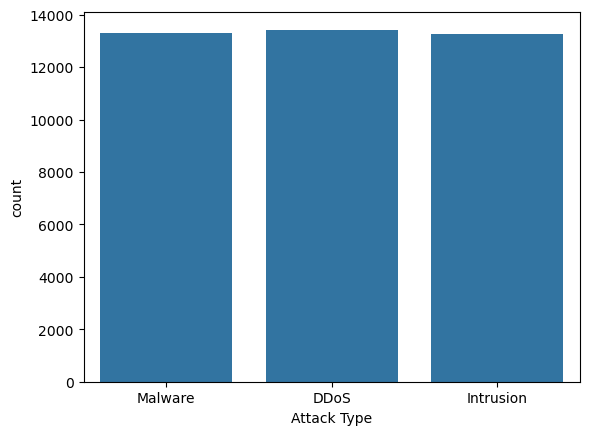

In [26]:
sns.countplot(x='Attack Type', data=df)

#### Conclusion for section 3: The dataset contains 3 attack classes. The distribution of classes is approximately balanced, with each class containing ~13,000 samples. This reduces bias risk and supports reliable supervised learning.

## 4. Exploratory Data Analysis

### 4.1 Examinig numeric varibles

In [27]:
df.head()

,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,Network Segment,Geo-location Data,Firewall Logs,IDS/IPS Alerts,Log Source,Hour,DayOfWeek
0,ICMP,503,Data,HTTP,IoC Detected,28.67,NaN,Malware,Known Pattern B,Logged,Low,Segment A,"Jamshedpur, Sikkim",Log Data,NaN,Server,6,1
1,ICMP,1174,Data,HTTP,IoC Detected,51.50,NaN,Malware,Known Pattern A,Blocked,Low,Segment B,"Bilaspur, Nagaland",Log Data,NaN,Firewall,7,2
2,UDP,306,Control,HTTP,IoC Detected,87.42,Alert Triggered,DDoS,Known Pattern B,Ignored,Low,Segment C,"Bokaro, Rajasthan",Log Data,Alert Data,Firewall,8,6
3,UDP,385,Data,HTTP,NaN,15.79,Alert Triggered,Malware,Known Pattern B,Blocked,Medium,Segment B,"Jaunpur, Rajasthan",NaN,Alert Data,Firewall,10,6
4,TCP,1462,Data,DNS,NaN,0.52,Alert Triggered,DDoS,Known Pattern B,Blocked,Low,Segment C,"Anantapur, Tripura",NaN,Alert Data,Firewall,13,6


In [28]:
numeric_var

['Packet Length', 'Anomaly Scores', 'Hour', 'DayOfWeek']

In [29]:
df[numeric_var].describe()

,Packet Length,Anomaly Scores,Hour,DayOfWeek
count,40000.000000,40000.000000,40000.000000,40000.000000
mean,781.452725,50.113473,11.507350,2.995750
std,416.044192,28.853598,6.919122,2.004515
min,64.000000,0.000000,0.000000,0.000000
25%,420.000000,25.150000,5.000000,1.000000
50%,782.000000,50.345000,12.000000,3.000000
75%,1143.000000,75.030000,17.000000,5.000000
max,1500.000000,100.000000,23.000000,6.000000


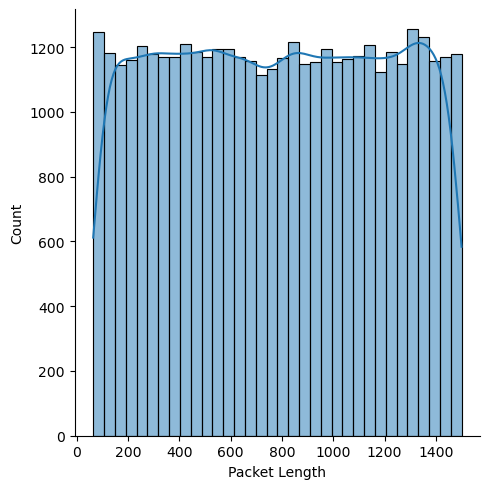

In [30]:
sns.displot(df["Packet Length"], kde=True)

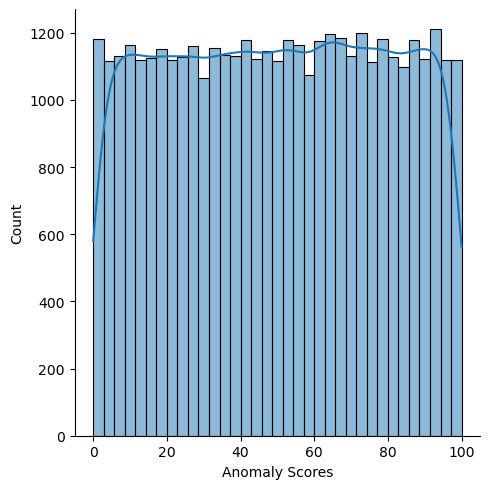

In [31]:
sns.displot(df["Anomaly Scores"], kde=True)

<Axes: xlabel='Hour', ylabel='count'>

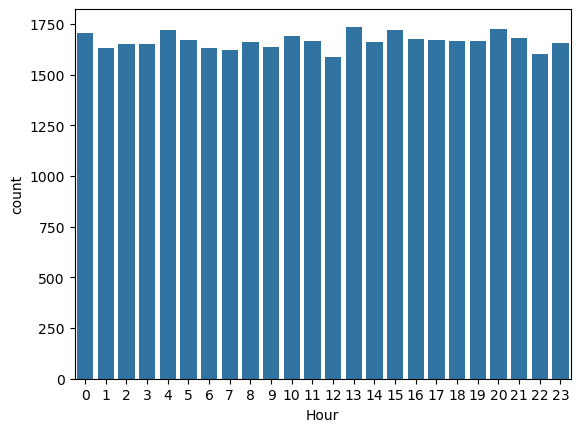

In [32]:
sns.countplot(x="Hour", data=df)

<Axes: xlabel='DayOfWeek', ylabel='count'>

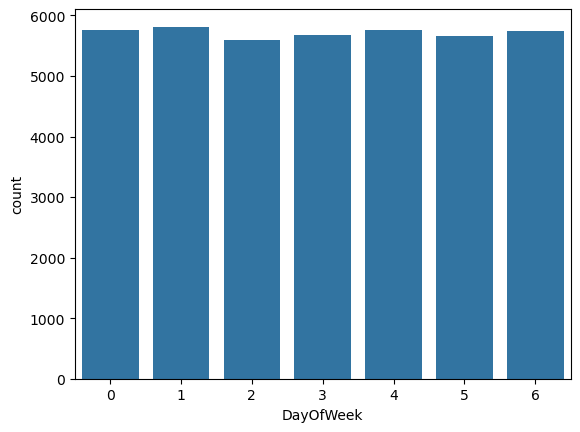

In [33]:
sns.countplot(x="DayOfWeek", data=df)

### conclusion:
The numerical variables in this dataset show a mix of realistic and engineered patterns.

Packet Length displays a strong and realistic spread (64–1500 bytes) with high variance, suggesting meaningful variability in network traffic behaviour.
Anomaly Scores are tightly bounded between 0 and 100 with a near-perfect symmetric distribution around the mean (~50), which strongly suggests this feature is normalised or artificially constructed rather than derived from raw system behaviour.
Hour and DayOfWeek cover their full expected ranges but appear uniformly distributed, indicating no clear temporal traffic patterns such as peak usage hours or weekday/weekend variation.

Overall, while the dataset contains some realistic signal (especially Packet Length), several features appear preprocessed, balanced, or synthetic, reducing the presence of natural-world irregularities such as skew, clustering, or time-based spikes.

# 4.2 Examining Categorical Varibles

In [34]:
df.head()

,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,Network Segment,Geo-location Data,Firewall Logs,IDS/IPS Alerts,Log Source,Hour,DayOfWeek
0,ICMP,503,Data,HTTP,IoC Detected,28.67,NaN,Malware,Known Pattern B,Logged,Low,Segment A,"Jamshedpur, Sikkim",Log Data,NaN,Server,6,1
1,ICMP,1174,Data,HTTP,IoC Detected,51.50,NaN,Malware,Known Pattern A,Blocked,Low,Segment B,"Bilaspur, Nagaland",Log Data,NaN,Firewall,7,2
2,UDP,306,Control,HTTP,IoC Detected,87.42,Alert Triggered,DDoS,Known Pattern B,Ignored,Low,Segment C,"Bokaro, Rajasthan",Log Data,Alert Data,Firewall,8,6
3,UDP,385,Data,HTTP,NaN,15.79,Alert Triggered,Malware,Known Pattern B,Blocked,Medium,Segment B,"Jaunpur, Rajasthan",NaN,Alert Data,Firewall,10,6
4,TCP,1462,Data,DNS,NaN,0.52,Alert Triggered,DDoS,Known Pattern B,Blocked,Low,Segment C,"Anantapur, Tripura",NaN,Alert Data,Firewall,13,6


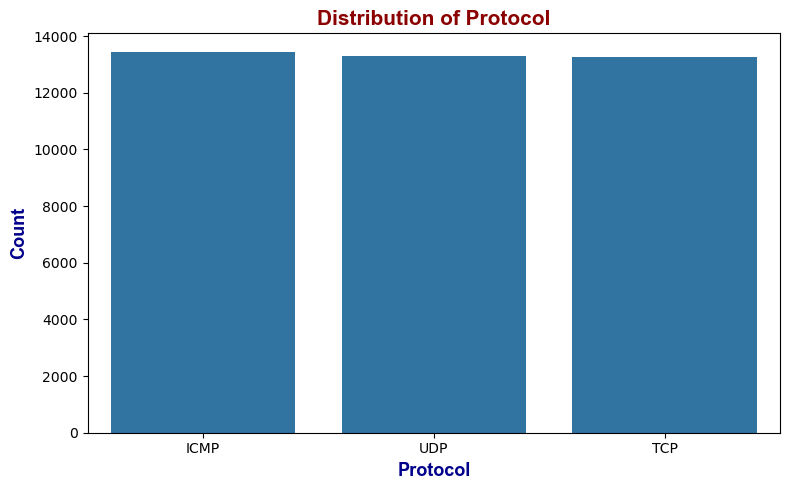

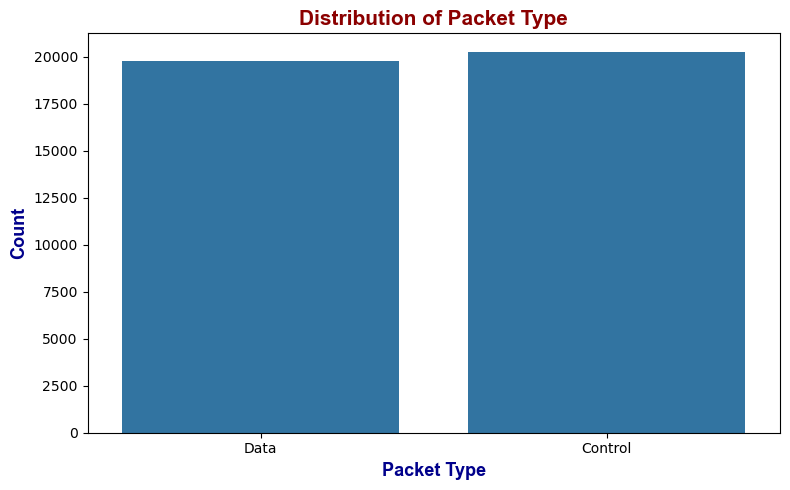

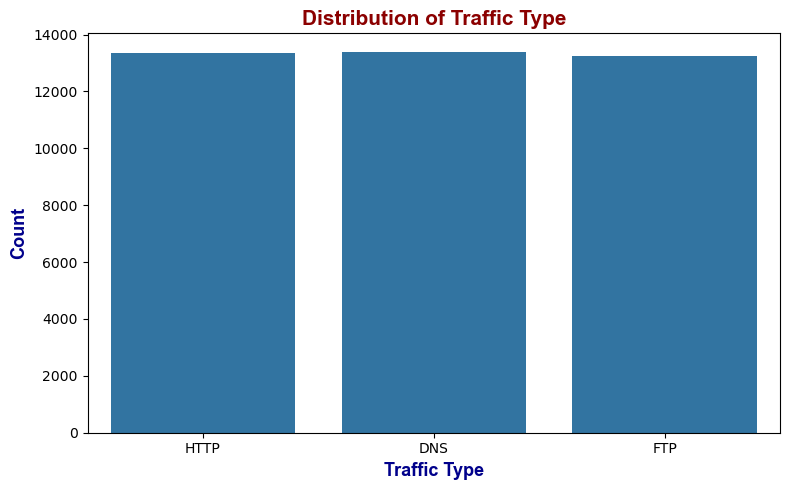

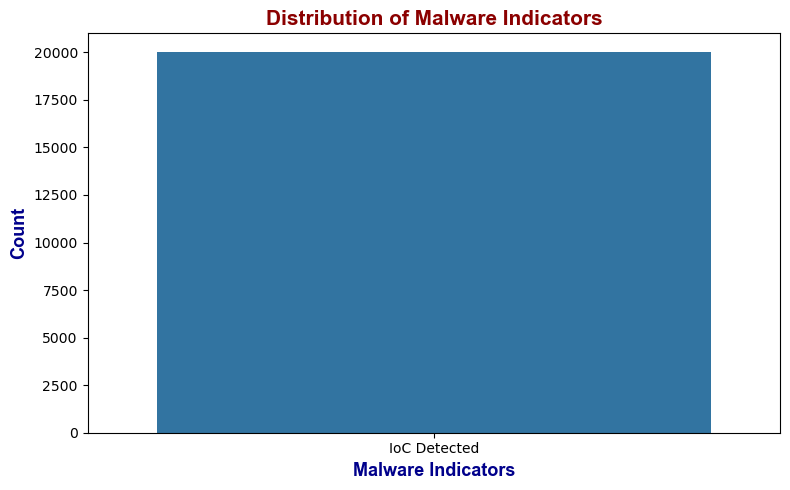

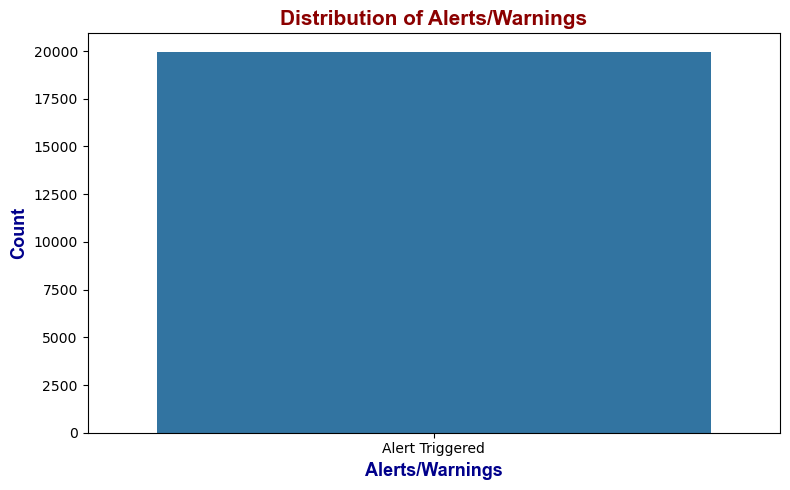

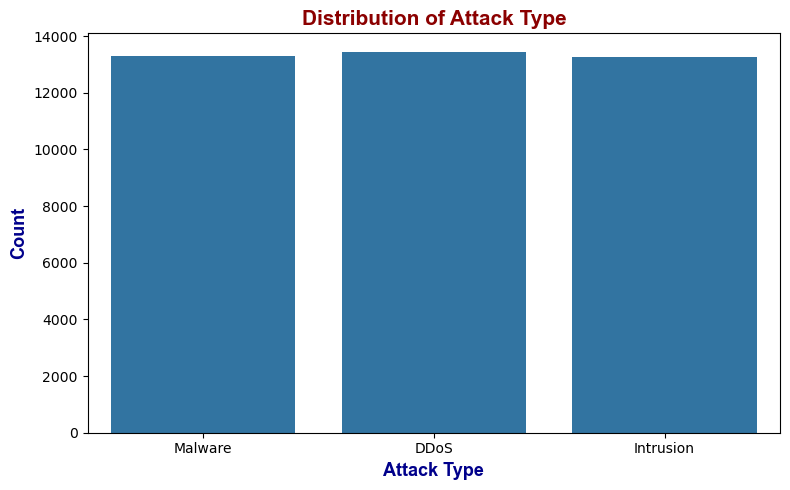

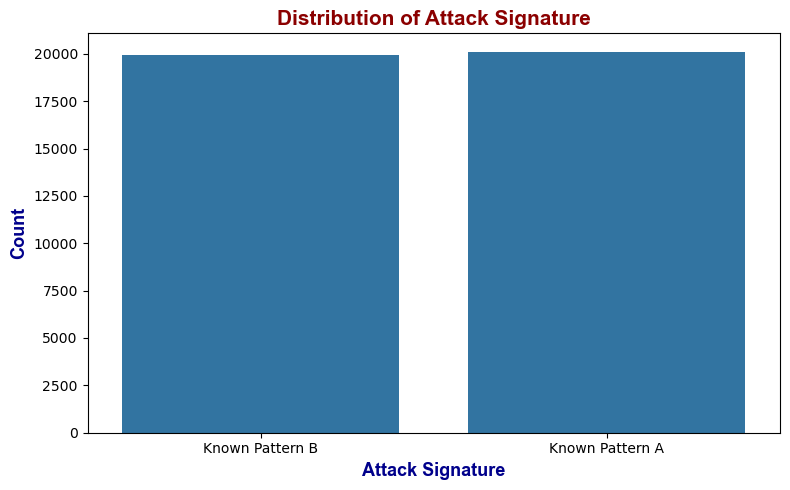

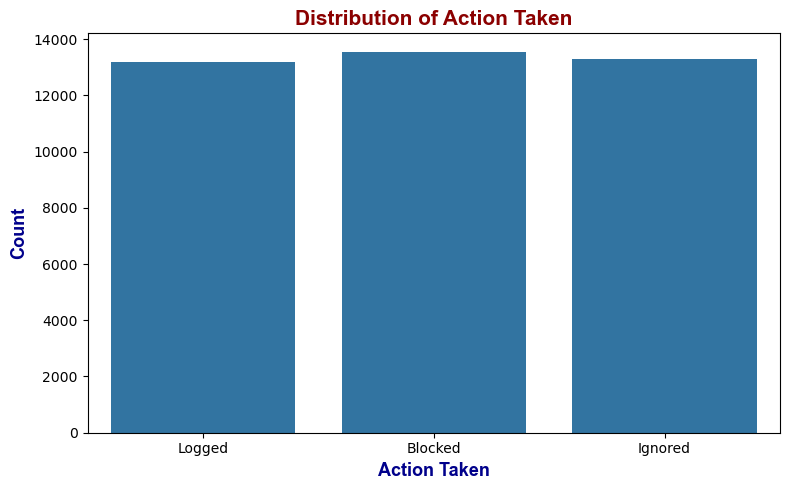

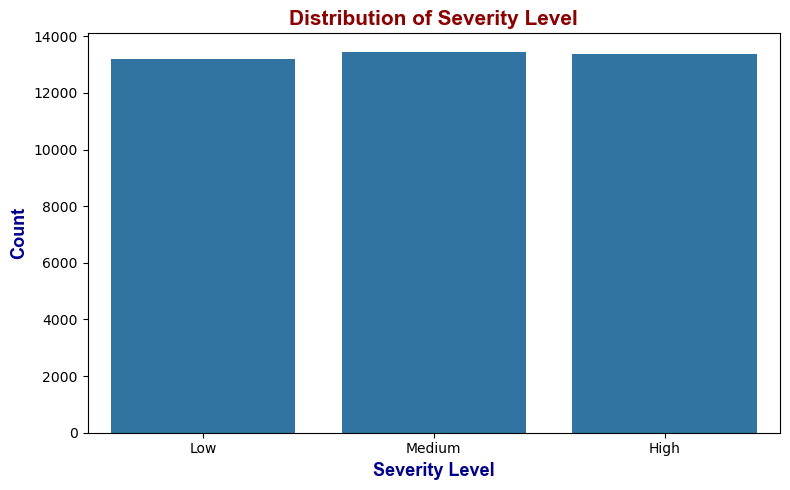

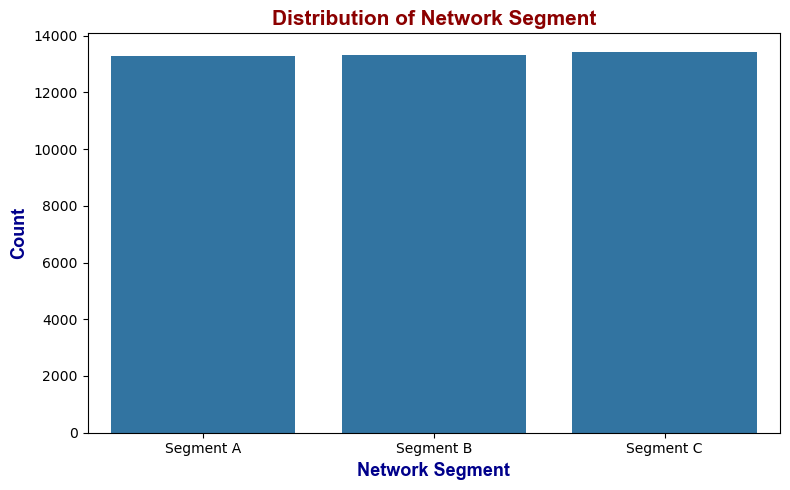

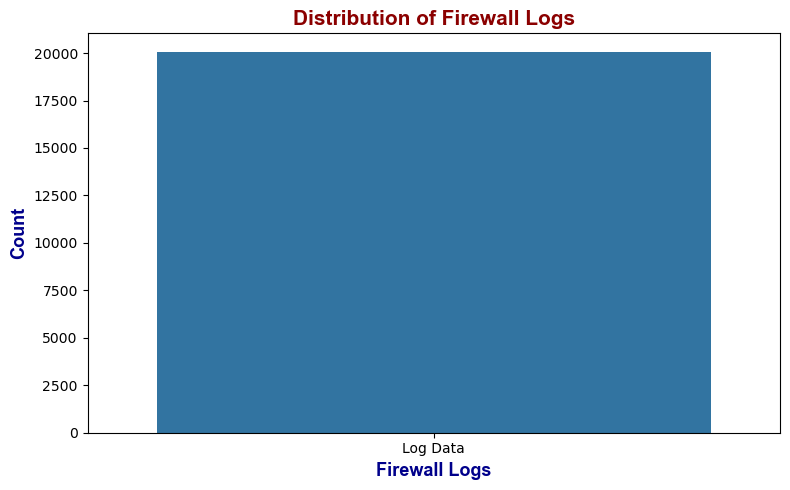

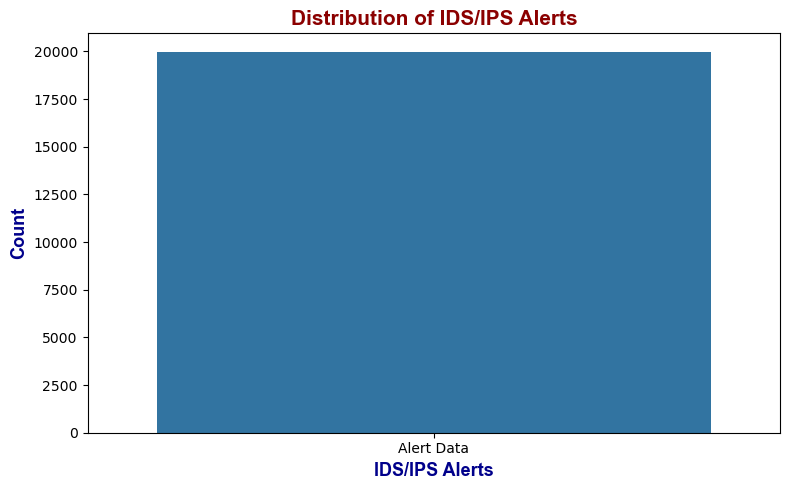

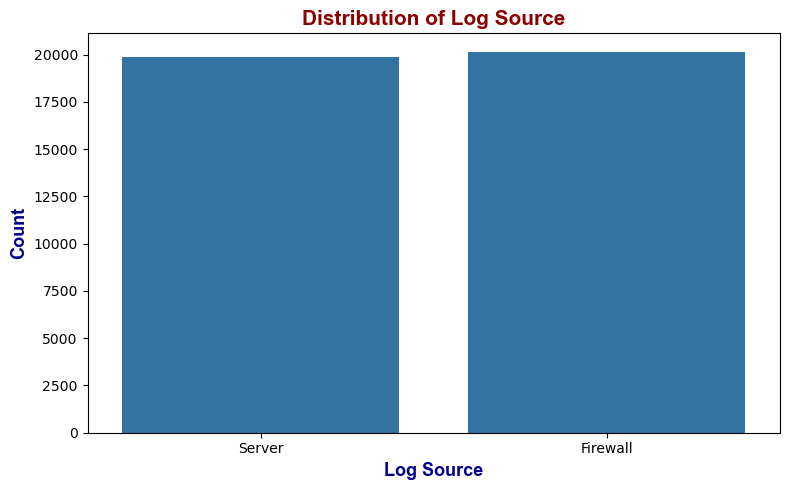

In [35]:
title_font = {"family": "arial", "color": "darkred", "weight": "bold", "size": 15}
axis_font = {"family": "arial", "color": "darkblue", "weight": "bold", "size": 13}

for col in [c for c in categorical_var if df[c].nunique() < 20]:
    plt.figure(figsize=(8, 5))

    sns.countplot(x=df[col])  # better for distributions

    plt.title(f"Distribution of {col}", fontdict=title_font)
    plt.xlabel(col, fontdict=axis_font)
    plt.ylabel("Count", fontdict=axis_font)

    plt.tight_layout()
    plt.show()


In [36]:
df[categorical_var].nunique() < 20

Protocol               True
Packet Type            True
Traffic Type           True
Malware Indicators     True
Alerts/Warnings        True
Attack Type            True
Attack Signature       True
Action Taken           True
Severity Level         True
Network Segment        True
Geo-location Data     False
Firewall Logs          True
IDS/IPS Alerts         True
Log Source             True
dtype: bool

### Conclusion
The categorical variables in this dataset show signs of being partially engineered or preprocessed, rather than fully raw network traffic data.

The Packet Length feature displays a wide and realistic distribution (ranging approximately from 64 to 1500 bytes),correct range but missing natural structure. This suggests it retains meaningful structure and likely reflects semi-real network behaviour.

In contrast, several categorical features appear relatively balanced across their categories, with no strong skew or dominant classes.Like anomoly scores look uniformly assigned. This may indicate that the dataset has been normalized or synthetically generated to reduce imbalance, rather than reflecting naturally occurring network distributions.

The variable geo-location-data is a special case because it contains a very high number of unique values, making it difficult to visualise and analyse effectively using standard charts or categorical plots.

Overall, while there are indicators of realistic signal (particularly in Packet Length), the uniformity observed in multiple categorical variables suggests that parts of the dataset may have been preprocessed or artificially balanced. This reduces the presence of typical real-world patterns such as class imbalance, clustering, or temporal spikes.

# 4.3 Examining Anomoly score

In [37]:
df["Anomaly Scores"].nunique()

9826

In [38]:
df["Anomaly Scores"].describe()

count    40000.000000
mean        50.113473
std         28.853598
min          0.000000
25%         25.150000
50%         50.345000
75%         75.030000
max        100.000000
Name: Anomaly Scores, dtype: float64

In [39]:
df["Anomaly Scores"].median()

50.345

<Axes: xlabel='Anomaly Scores'>

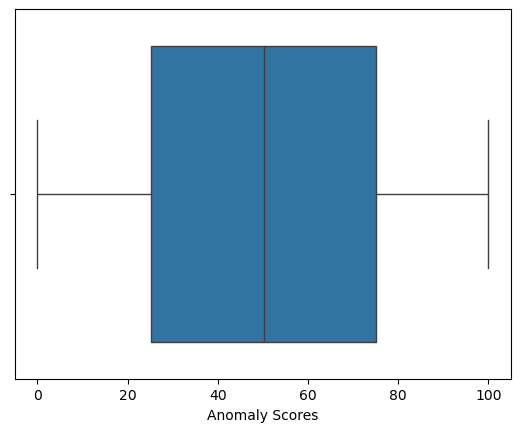

In [40]:
sns.boxplot(x="Anomaly Scores", data=df,vert=False)

## Conclusion:
- The anomaly scores are evenly distributed across the dataset.
- The mean and median values are very close together, which further suggests that the data may be synthetically generated or heavily pre-processed rather than accurately simulating real-world anomaly score behaviour.

# 5. Attack Pattern Exploration


## 5.1 Numerical Varible - Attacktype 



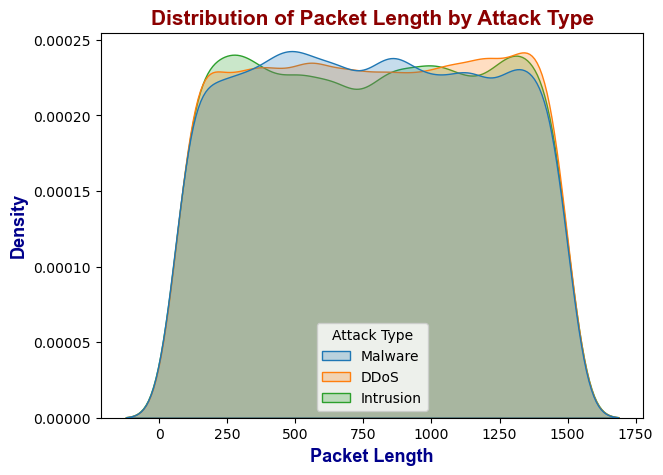

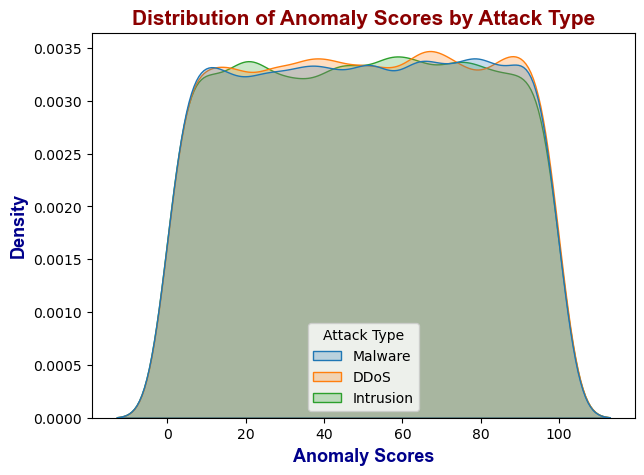

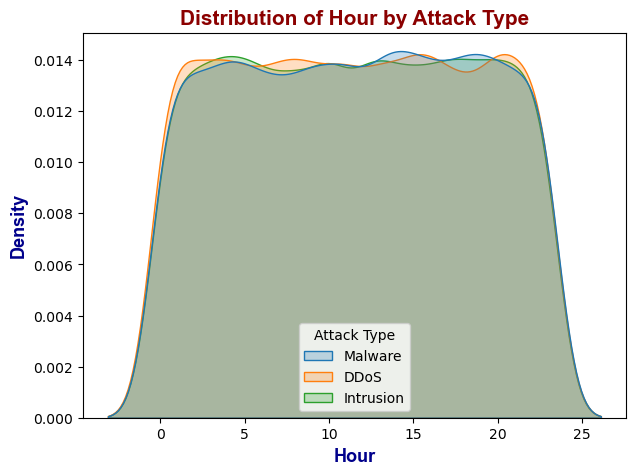

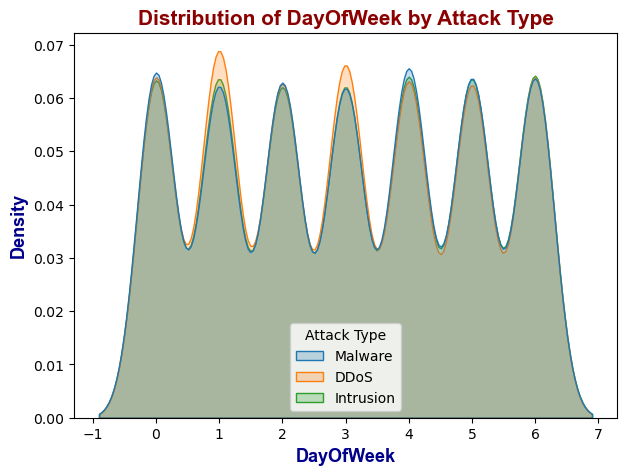

In [41]:
title_font = {
    "family": "arial",
    "color": "darkred",
    "weight": "bold",
    "size": 15
}

axis_font = {
    "family": "arial",
    "color": "darkblue",
    "weight": "bold",
    "size": 13
}

for i in numeric_var:
    
    plt.figure(figsize=(7,5))

    sns.kdeplot(
        data=df,
        x=i,
        hue="Attack Type",
        fill=True
    )

    plt.title(f"Distribution of {i} by Attack Type", fontdict=title_font)
    plt.xlabel(i, fontdict=axis_font)
    plt.ylabel("Density", fontdict=axis_font)

    plt.show()

In [42]:
df[numeric_var].corr()

,Packet Length,Anomaly Scores,Hour,DayOfWeek
Packet Length,1.000000,-0.003599,0.004572,-0.008379
Anomaly Scores,-0.003599,1.000000,0.001039,0.000303
Hour,0.004572,0.001039,1.000000,-0.004692
DayOfWeek,-0.008379,0.000303,-0.004692,1.000000


## Conclusion:
- The distributions of the numerical variables and attack types are relatively even, with no strong skew or dominant category, suggesting a highly balanced dataset without clear real-world bias or patterns.dropped later
- The numerical variables show very weak correlations with one another, indicating a lack of meaningful linear relationships between features.
-This suggests that some numerical features may provide limited predictive value individually and could be considered for feature reduction during later stages of modelling, depending on model performance.